## Crop Yield Prediction (Agriculture)

## Domain

Agriculture + Machine Learning (Regression)
This project focuses on predicting crop yield using environmental, soil, and management factors. Accurate yield prediction helps farmers optimize inputs, reduce risk, and improve agricultural planning.


## Problem Statement

Predict crop yield (tons per hectare) using machine learning based on features such as:
Rainfall


Temperature


Soil nutrients (NPK levels, pH)


Fertilizer input


Irrigation


Humidity, sunlight hours


Crop variety, soil type


This enables data-driven decisions for yield optimization and sustainable agriculture.


##  Architecture / ML Workflow

## Data Loading & Cleaning

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("C:\\Users\\gopus\\Downloads\\crop_yield 27k.csv")
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [3]:
df.shape

(1000000, 10)

## Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), object(4)
memory usage: 62.9+ MB


In [5]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [6]:
df.duplicated().sum()

0

In [7]:
df.isnull().sum()

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64

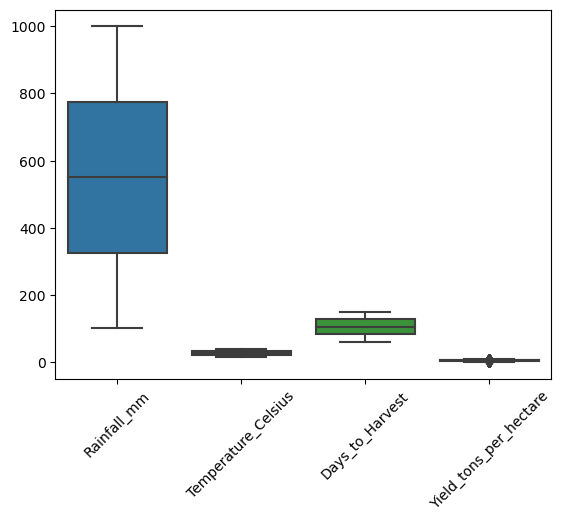

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=45)
plt.show()

## Visualization

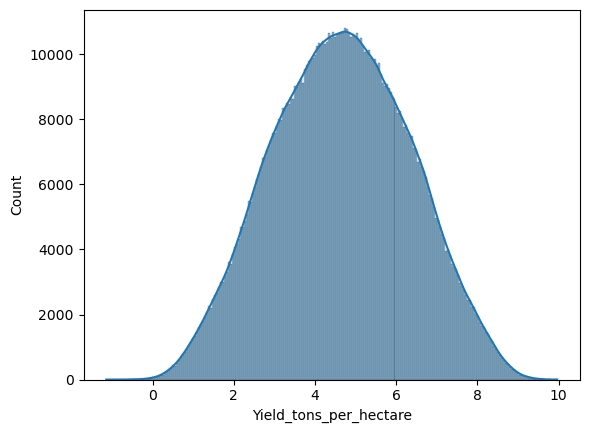

In [9]:
sns.histplot(df['Yield_tons_per_hectare'], kde=True)
plt.show()

In [10]:
import warnings
warnings.filterwarnings('ignore')

<Axes: >

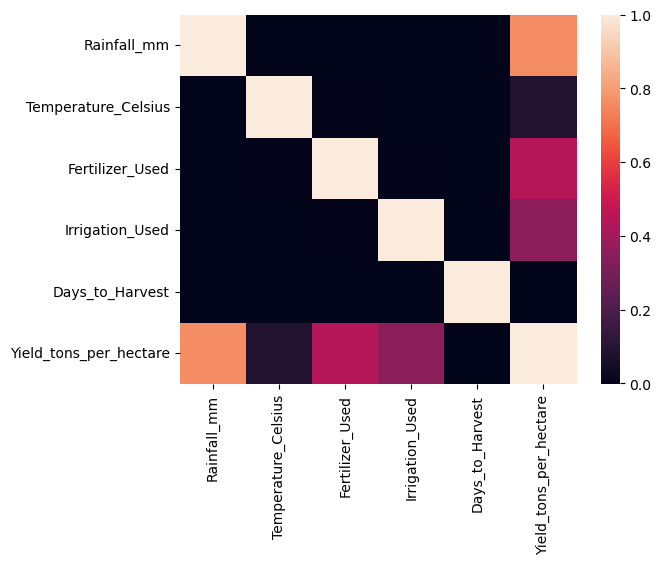

In [11]:
import seaborn as sns
sns.heatmap(df.corr())

## Train Test split

In [12]:
X = df.drop('Yield_tons_per_hectare', axis=1)
y = df['Yield_tons_per_hectare']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
numerical_cols = ['Rainfall_mm','Temperature_Celsius','Days_to_Harvest']
categorical_cols = ['Region','Soil_Type','Crop','Weather_Condition']
bool_cols = ['Fertilizer_Used','Irrigation_Used']

## Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(), categorical_cols),
    ('bool', OrdinalEncoder(), bool_cols)
])

In [16]:
X_train_transformed = ct.fit_transform(X_train)
X_test_transformed = ct.transform(X_test)

In [17]:
import pandas as pd
feature_names = ct.get_feature_names_out()
X_train_transformed_df = pd.DataFrame(X_train_transformed,columns=feature_names)
X_train_transformed_df.head()

,num__Rainfall_mm,num__Temperature_Celsius,num__Days_to_Harvest,cat__Region_East,cat__Region_North,cat__Region_South,cat__Region_West,cat__Soil_Type_Chalky,cat__Soil_Type_Clay,cat__Soil_Type_Loam,...,cat__Crop_Cotton,cat__Crop_Maize,cat__Crop_Rice,cat__Crop_Soybean,cat__Crop_Wheat,cat__Weather_Condition_Cloudy,cat__Weather_Condition_Rainy,cat__Weather_Condition_Sunny,bool__Fertilizer_Used,bool__Irrigation_Used
0,1.299211,0.767268,-0.980873,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0
1,-1.426747,-0.389472,-0.634162,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.382829,0.352719,0.598590,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-1.263925,-1.108459,-0.133356,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.720423,-1.285003,-0.634162,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [18]:
feature_names = ct.get_feature_names_out()

X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)
X_test_transformed_df.head()

,num__Rainfall_mm,num__Temperature_Celsius,num__Days_to_Harvest,cat__Region_East,cat__Region_North,cat__Region_South,cat__Region_West,cat__Soil_Type_Chalky,cat__Soil_Type_Clay,cat__Soil_Type_Loam,...,cat__Crop_Cotton,cat__Crop_Maize,cat__Crop_Rice,cat__Crop_Soybean,cat__Crop_Wheat,cat__Weather_Condition_Cloudy,cat__Weather_Condition_Rainy,cat__Weather_Condition_Sunny,bool__Fertilizer_Used,bool__Irrigation_Used
0,0.635117,-0.503488,0.598590,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.196133,-0.614983,-1.019397,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.970870,-0.483508,1.369060,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
3,-1.332717,-1.470356,-0.325974,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.151367,-1.261531,-1.520202,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [19]:
X_train_transformed_df.shape

(800000, 24)

## Linear Reg

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train_transformed_df, y_train)

y_pred_lr = lr.predict(X_test_transformed_df)

print("Linear Regression")
print("Test R2:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
y_train_pred = lr.predict(X_train_transformed_df)
print("Train R²:", r2_score(y_train, y_train_pred))

Linear Regression
Test R2: 0.9130137709140372
MAE: 0.3995540808713492
Train R²: 0.9129706417514694


## KNN algo

In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_transformed_df, y_train)

y_pred_knn = knn.predict(X_test_transformed_df)

print("KNN Regressor")
print("R2:", r2_score(y_test, y_pred_knn))
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
#y_train_pred = knn.predict(X_train_transformed_df)
#print("Train R²:", r2_score(y_train, y_train_pred))

KNN Regressor
R2: 0.8859297971818054
MAE: 0.4573203643363739


## DT

In [22]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train_transformed_df, y_train)

y_pred_dt = dt.predict(X_test_transformed_df)

print("Decision Tree")
print("test R2:", r2_score(y_test, y_pred_dt))
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
y_train_pred = dt.predict(X_train_transformed_df)
print("Train R²:", r2_score(y_train, y_train_pred))

Decision Tree
test R2: 0.9120098428420607
MAE: 0.40182800633595916
Train R²: 0.9134227952585111


## RandomForest Algo

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_transformed_df, y_train)
y_pred = model.predict(X_test_transformed_df)

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.41148495719722444
MSE: 0.2659762149273225
RMSE: 0.2659762149273225
R2: 0.9077415451172841


In [ ]:
from sklearn.metrics import r2_score

# Predictions
y_train_pred = model.predict(X_train_transformed_df)


# R² scores
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Training R²: {r2_train:.4f}")
print(f"Test R²: {r2_test:.4f}")

## XGBoost Algo

In [22]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
models = xgb.XGBRegressor(
    n_estimators=500,       # number of trees
    learning_rate=0.05,     # smaller learning rate for stability
    max_depth=6,            # limit depth to reduce overfitting
    subsample=0.8,          # use 80% of data per tree
    colsample_bytree=0.8,   # use 80% of features per tree
    tree_method='hist',     # faster for large datasets
    n_jobs=-1,              # use all CPU cores
    random_state=42
)

# 7️⃣ Train the model
models.fit(X_train_transformed_df, y_train)

# 8️⃣ Predictions
y_pred = models.predict(X_test_transformed_df)
y_train_pred = models.predict(X_train_transformed_df)

# 9️⃣ Evaluation
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

Train R²: 0.9141753139537955
Test R²: 0.9127755319870078
MAE: 0.40010626940043537
MSE: 0.25146349871822204
RMSE: 0.25146349871822204


In [84]:
X_train_transformed_df.columns

Index(['num__Rainfall_mm', 'num__Temperature_Celsius', 'num__Days_to_Harvest',
       'cat__Region_East', 'cat__Region_North', 'cat__Region_South',
       'cat__Region_West', 'cat__Soil_Type_Chalky', 'cat__Soil_Type_Clay',
       'cat__Soil_Type_Loam', 'cat__Soil_Type_Peaty', 'cat__Soil_Type_Sandy',
       'cat__Soil_Type_Silt', 'cat__Crop_Barley', 'cat__Crop_Cotton',
       'cat__Crop_Maize', 'cat__Crop_Rice', 'cat__Crop_Soybean',
       'cat__Crop_Wheat', 'cat__Weather_Condition_Cloudy',
       'cat__Weather_Condition_Rainy', 'cat__Weather_Condition_Sunny',
       'bool__Fertilizer_Used', 'bool__Irrigation_Used'],
      dtype='object')

In [23]:
import joblib

joblib.dump(ct, "preprocessor.pkl")
joblib.dump(models, "model.pkl")

['model.pkl']